In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

from ultralytics import YOLO

import ipywidgets as widgets
from IPython.display import display, clear_output

YOLK, EGG, PARSLEY = 0, 1, 2

### Загрузка данных

In [2]:
train_dir = Path("data/train")
valid_dir = Path("data/valid")
image_paths = sorted(train_dir.glob("*.jpg"))
print("Картинок в train:", len(image_paths))

Картинок в train: 199


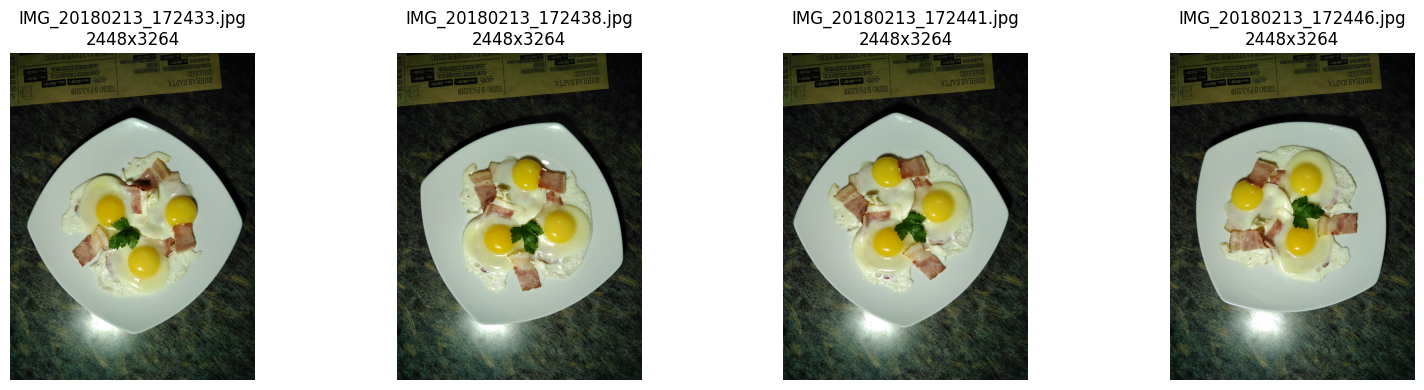

In [3]:
# визуализация: первые 4 картинки с их размерами
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, path in zip(axes, image_paths[:4]):
    img = cv2.imread(str(path))
    if img is None:
        print("Не прочиталось:", path)
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR -> RGB
    h, w = img.shape[:2]
    ax.imshow(img)
    ax.set_title(f"{path.name}\n{w}x{h}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Сегментация (YOLO-seg)

In [4]:
# обучение сегментации на ручной разметке (30 картинок)
model_seg = YOLO("yolo11n-seg.pt")
model_seg.train(
    data="data/YOLO/data.yaml",
    epochs=50,
    imgsz=1024,
    batch=2,   # уменьши, если мало памяти GPU
)

In [11]:
# загружаем обученную модель сегментации
yolo = YOLO("data/yolo_best.pt")

# проверка предсказания на одной картинке
results = yolo.predict(source="data/train/IMG_20180213_172433.jpg", save=False, imgsz=1024)


image 1/1 D:\School21\DS8_Fried_Eggs\src\data\train\IMG_20180213_172433.jpg: 1024x768 3 yolks, 1 egg, 1 parsley, 114.7ms
Speed: 9.3ms preprocess, 114.7ms inference, 3.6ms postprocess per image at shape (1, 3, 1024, 768)


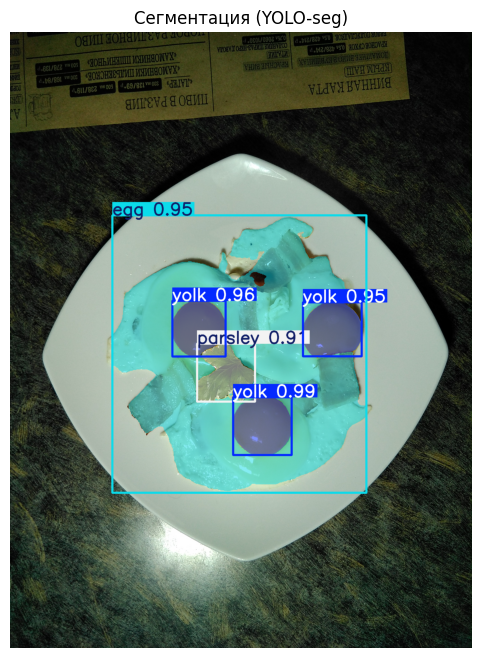

In [23]:
img = results[0].plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.title('Сегментация (YOLO-seg)')
plt.imshow(img)
plt.axis("off")
plt.show()

### Активное обучение: авто-разметка неразмеченных

In [24]:
CONF = 0.8  # порог уверенности для приёма авто-разметки

def generate_labels(src_dir, out_labels, skip_stems):
    # прогоняем сегментацию по картинкам, принимаем уверенные -> txt (YOLO-seg)
    out_labels.mkdir(parents=True, exist_ok=True)
    accepted, rejected = [], []

    for img_path in Path(src_dir).glob("*.jpg"):
        if img_path.stem in skip_stems:
            continue
        result = yolo.predict(img_path, imgsz=768, conf=CONF, verbose=False)[0]

        if result.masks is None or len(result.boxes) == 0:
            rejected.append((img_path.name, "нет объектов"))
            continue

        mean_conf = result.boxes.conf.mean().item()
        if mean_conf >= CONF:
            lines = []
            for cls_id, poly in zip(result.boxes.cls.tolist(), result.masks.xyn):
                coords = " ".join(f"{x:.6f}" for pt in poly for x in pt)
                lines.append(f"{int(cls_id)} {coords}")
            (out_labels / f"{img_path.stem}.txt").write_text("\n".join(lines))
            accepted.append((img_path.name, round(mean_conf, 2)))
        else:
            rejected.append((img_path.name, f"conf={mean_conf:.2f}"))

    print(f"Принято: {len(accepted)}  |  Отклонено: {len(rejected)}")
    for r in rejected[:10]:
        print("  отклонено:", r)

In [25]:
# уже размеченные вручную (их не трогаем)
labeled_stems = {p.stem for p in Path("data/YOLO/labels/train").glob("*.txt")}

# авто-разметка train (то, что не размечено руками)
generate_labels("data/train", Path("data/YOLO/labels/valid"), labeled_stems)

# авто-разметка глобального теста
generate_labels("data/test", Path("data/YOLO/labels/test"), set())

Принято: 169  |  Отклонено: 0
Принято: 65  |  Отклонено: 0


### Ручная разметка и правка классов

In [27]:
IMG_DIR = Path("data/train")
CSV_PATH = "data/image_classes.csv"

df_lbl = pd.read_csv(CSV_PATH)

choice = input("Режим (1=train, 2=valid, 3=unlabeled): ")
mode_map = {"1": "train", "2": "valid", "3": "unlabeled"}
mode = mode_map.get(choice)

to_label = []
if mode is None:
    print("Неверный выбор")
else:
    sub = df_lbl[df_lbl["mode"] == mode]
    if "entropy" in sub.columns:
        sub = sub.sort_values("entropy", ascending=False)  # неуверенные сверху
    to_label = sub.index.tolist()
    print(f"К разметке: {len(to_label)} картинок")

state = {"pos": 0}
out = widgets.Output()

def show():
    with out:
        clear_output(wait=True)
        if state["pos"] >= len(to_label):
            print("Готово! Размечено в этой сессии.")
            return
        i = to_label[state["pos"]]
        row = df_lbl.loc[i]
        print(f"[{state['pos']+1}/{len(to_label)}]  {row['filename']}")
        print(f"  Текущий класс: {row['class']}")
        # подсказки модели, если уже есть
        if "pred_class" in row and pd.notna(row.get("pred_class")):
            print(f"  Модель: {int(row['pred_class'])}  энтропия {row.get('entropy', float('nan')):.2f}")
        display(Image.open(IMG_DIR / row["filename"]).resize((500, 375)))

def make_handler(cls):
    def handler(b):
        i = to_label[state["pos"]]
        df_lbl.loc[i, "class"] = cls
        df_lbl.to_csv(CSV_PATH, index=False)  # автосохранение
        state["pos"] += 1
        show()
    return handler

buttons = [widgets.Button(description=f"Класс {c}", layout=widgets.Layout(width="80px"))
           for c in range(6)]
for c, btn in enumerate(buttons):
    btn.on_click(make_handler(c))

skip = widgets.Button(description="Пропустить →", button_style="warning",
                      layout=widgets.Layout(width="110px"))
skip.on_click(make_handler(-1))

back = widgets.Button(description="← Назад", layout=widgets.Layout(width="90px"))
def go_back(b):
    if state["pos"] > 0:
        state["pos"] -= 1
        show()
back.on_click(go_back)

display(widgets.HBox(buttons + [skip, back]), out)
show()

К разметке: 0 картинок


Output()

### Препроцессинг: центрирование + resize

In [28]:
def load_polygons(txt_path):
    # txt YOLO-seg -> список (class_id, точки в нормализованных координатах)
    polys = []
    for line in Path(txt_path).read_text().splitlines():
        parts = line.split()
        if len(parts) < 7:   # класс + минимум 3 точки
            continue
        polys.append((int(parts[0]),
                      np.array([float(v) for v in parts[1:]]).reshape(-1, 2)))
    return polys


def center_and_resize(img_path, txt_path, target_w=1024, target_h=768, margin=1.2):
    # центрирует по маске яичницы (egg), обрезает и приводит к target
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    polys = load_polygons(txt_path)
    eggs = [c for cls, c in polys if cls == EGG]
    if not eggs:
        return cv2.resize(img, (target_w, target_h))  # нет маски -> просто resize

    pts = np.vstack(eggs) * np.array([w, h])
    cx, cy = pts.mean(axis=0)                          # центр масс яичницы
    bw = (pts[:, 0].max() - pts[:, 0].min()) * margin
    bh = (pts[:, 1].max() - pts[:, 1].min()) * margin
    half = max(bw, bh) / 2                              # квадратный вырез

    x1, y1 = max(0, int(cx - half)), max(0, int(cy - half))
    x2, y2 = min(w, int(cx + half)), min(h, int(cy + half))
    crop = img[y1:y2, x1:x2]

    ch, cw = crop.shape[:2]
    s = min(target_w / cw, target_h / ch)
    nw, nh = int(cw * s), int(ch * s)
    resized = cv2.resize(crop, (nw, nh))
    canvas = np.zeros((target_h, target_w, 3), dtype=img.dtype)
    ox, oy = (target_w - nw) // 2, (target_h - nh) // 2
    canvas[oy:oy+nh, ox:ox+nw] = resized
    return canvas


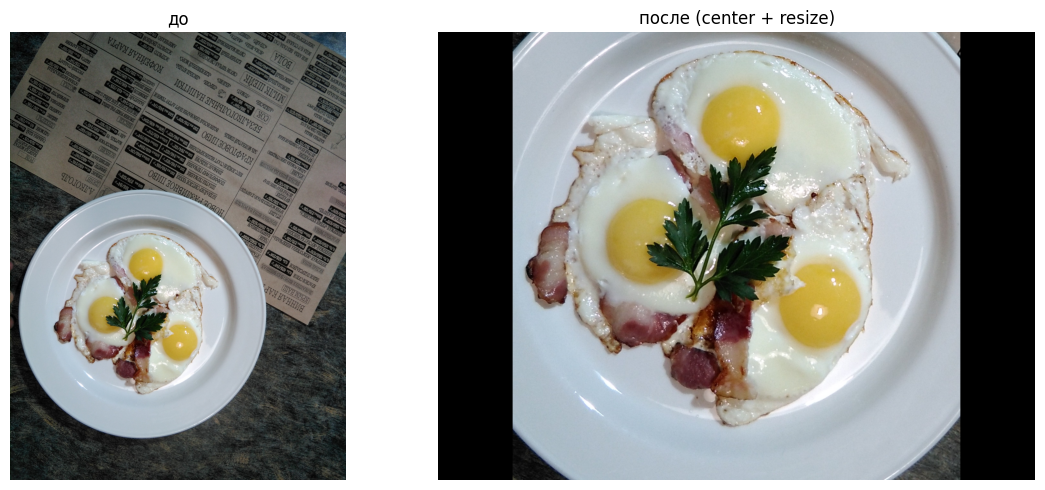

In [31]:
# визуализация: препроцессинг до/после на одной картинке
sample_img = "data/train/IMG_20180213_174912.jpg"
sample_txt = "data/YOLO/labels/valid/IMG_20180213_174912.txt"

orig = cv2.cvtColor(cv2.imread(sample_img), cv2.COLOR_BGR2RGB)
proc = center_and_resize(sample_img, sample_txt)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(orig); ax[0].set_title("до"); ax[0].axis("off")
ax[1].imshow(proc); ax[1].set_title("после (center + resize)"); ax[1].axis("off")
plt.tight_layout()
plt.show()

### Классификация: CNN на картинке + масках (6 каналов)

In [32]:
def build_input(img_path, txt_path, size=224, augment=False):
    # 6-канальный вход: RGB + маски желтка/белка/петрушки; augment - синхронная аугментация
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    polys = load_polygons(txt_path)
    mask_yolk = np.zeros((h, w), dtype=np.float32)
    mask_egg = np.zeros((h, w), dtype=np.float32)
    mask_parsley = np.zeros((h, w), dtype=np.float32)
    for cls, coords in polys:
        pts = (coords * np.array([w, h])).astype(np.int32)
        if cls == YOLK:
            cv2.fillPoly(mask_yolk, [pts], 1.0)
        elif cls == EGG:
            cv2.fillPoly(mask_egg, [pts], 1.0)
        elif cls == PARSLEY:
            cv2.fillPoly(mask_parsley, [pts], 1.0)

    img = cv2.resize(img, (size, size)).astype(np.float32) / 255.0
    mask_yolk = cv2.resize(mask_yolk, (size, size))
    mask_egg = cv2.resize(mask_egg, (size, size))
    mask_parsley = cv2.resize(mask_parsley, (size, size))

    if augment:
        # геометрия применяется одинаково к картинке и всем маскам
        angle = np.random.uniform(0, 360)
        M = cv2.getRotationMatrix2D((size / 2, size / 2), angle, 1.0)
        img = cv2.warpAffine(img, M, (size, size))
        mask_yolk = cv2.warpAffine(mask_yolk, M, (size, size))
        mask_egg = cv2.warpAffine(mask_egg, M, (size, size))
        mask_parsley = cv2.warpAffine(mask_parsley, M, (size, size))
        if np.random.rand() < 0.5:
            img = img[:, ::-1].copy()
            mask_yolk = mask_yolk[:, ::-1].copy()
            mask_egg = mask_egg[:, ::-1].copy()
            mask_parsley = mask_parsley[:, ::-1].copy()

    stacked = np.dstack([img, mask_yolk, mask_egg, mask_parsley])
    return torch.from_numpy(stacked).permute(2, 0, 1).float()


class EggDataset(Dataset):
    def __init__(self, df, img_dir, txt_map, size=224, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.txt_map = txt_map
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        stem = Path(row["filename"]).stem
        x = build_input(self.img_dir / row["filename"], self.txt_map[stem],
                        self.size, augment=self.augment)
        # класс нужен только при обучении; на тесте его нет - заглушка -1
        y = int(row["class"]) if "class" in self.df.columns and pd.notna(row["class"]) else -1
        return x, y


def build_model_6ch(n_classes=6):
    # ResNet18 с первым слоем, расширенным с 3 до 6 каналов
    model = models.resnet18(weights="IMAGENET1K_V1")
    old = model.conv1
    new = nn.Conv2d(6, old.out_channels, kernel_size=old.kernel_size,
                    stride=old.stride, padding=old.padding, bias=False)
    with torch.no_grad():
        new.weight[:, :3] = old.weight  # RGB
        new.weight[:, 3:] = old.weight  # маски инициализируем весами RGB (3=3)
    model.conv1 = new
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model

### Обучение CNN

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_csv("data/image_classes.csv")
df_train_all = df[df["class"] != -1].copy()
df_train_all["class"] = df_train_all["class"].astype(int)

# карта txt: ручные (train) + авто (valid)
txt_map = {p.stem: p for p in Path("data/YOLO/labels/valid").glob("*.txt")}
txt_map.update({p.stem: p for p in Path("data/YOLO/labels/train").glob("*.txt")})

# train/valid 80/20, стратифицированно
train_df, valid_df = train_test_split(
    df_train_all, test_size=0.2, stratify=df_train_all["class"], random_state=42
)
print(f"Train: {len(train_df)}, Valid: {len(valid_df)}")

train_ds = EggDataset(train_df, "data/train", txt_map, augment=True)
valid_ds = EggDataset(valid_df, "data/train", txt_map, augment=False)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=8)

model = build_model_6ch(6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(10):
    model.train()
    total = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item()
    print(f"Эпоха {epoch+1}: train loss {total/len(train_loader):.4f}")

# оценка на valid
model.eval()
all_proba, all_true = [], []
with torch.no_grad():
    for x, y in valid_loader:
        proba = torch.softmax(model(x.to(device)), dim=1).cpu().numpy()
        all_proba.append(proba)
        all_true.extend(y.numpy())

all_proba = np.clip(np.vstack(all_proba), 1e-3, 1 - 1e-3)
all_proba = all_proba / all_proba.sum(axis=1, keepdims=True)
ll = log_loss(all_true, all_proba, labels=list(range(6)))
print(f"\n=== CNN log loss (valid): {ll:.4f} ===")

Train: 159, Valid: 40
Эпоха 1: train loss 1.5970
Эпоха 2: train loss 0.9835
Эпоха 3: train loss 0.7871
Эпоха 4: train loss 0.5580
Эпоха 5: train loss 0.4724
Эпоха 6: train loss 0.5569
Эпоха 7: train loss 0.4589
Эпоха 8: train loss 0.4394
Эпоха 9: train loss 0.3875
Эпоха 10: train loss 0.3951

=== CNN log loss (valid): 0.4941 ===


### Предсказание и уверенность (для активного обучения)

In [34]:
def predict_proba_cnn(model, sub_df, img_dir, txt_map, size=224):
    # прогоняет CNN по картинкам, возвращает вероятности (порядок сохраняется)
    model.eval()
    ds = EggDataset(sub_df, img_dir, txt_map, size=size, augment=False)
    loader = DataLoader(ds, batch_size=8, shuffle=False)
    out = []
    with torch.no_grad():
        for x, _ in loader:
            proba = torch.softmax(model(x.to(device)), dim=1).cpu().numpy()
            out.append(proba)
    return np.vstack(out)


def add_scores(sub_df, proba, mode):
    # добавляет mode, pred_class, max_proba, entropy
    proba = np.clip(proba, 1e-3, 1 - 1e-3)
    proba = proba / proba.sum(axis=1, keepdims=True)
    sub_df = sub_df.copy()
    sub_df["mode"] = mode
    sub_df["pred_class"] = proba.argmax(axis=1)
    sub_df["max_proba"] = proba.max(axis=1)
    sub_df["entropy"] = -np.sum(proba * np.log(proba + 1e-9), axis=1)
    return sub_df

In [36]:
# скорим train (проверка разметки), valid (честно) и неразмеченные (активное обучение)
train_scored = add_scores(train_df, predict_proba_cnn(model, train_df, "data/train", txt_map), "train")
valid_scored = add_scores(valid_df, predict_proba_cnn(model, valid_df, "data/train", txt_map), "valid")

unlabeled_df = df[df["class"] == -1].copy()
if len(unlabeled_df):
    unlabeled_scored = add_scores(unlabeled_df, predict_proba_cnn(model, unlabeled_df, "data/train", txt_map), "unlabeled")
    all_scored = pd.concat([train_scored, valid_scored, unlabeled_scored], ignore_index=True)
else:
    all_scored = pd.concat([train_scored, valid_scored], ignore_index=True)

all_scored.to_csv("data/image_classes.csv", index=False)
print("Сохранено!")

Сохранено!


### Предсказание для глобального теста

In [38]:
test_txt_map = {p.stem: p for p in Path("data/YOLO/labels/test").glob("*.txt")}

test_df = pd.read_csv("data/fried_eggs.csv")
if "class" not in test_df.columns:
    test_df["class"] = -1

proba_test = predict_proba_cnn(model, test_df, "data/test", test_txt_map)

# собираем результат: filename + вероятности по классам
proba_cols = [f"class_{c}" for c in range(6)]
result = pd.concat(
    [test_df[["filename"]].reset_index(drop=True),
     pd.DataFrame(proba_test, columns=proba_cols)],
    axis=1,
)
result.to_csv("data/submission.csv", index=False)
result.head()

,filename,class_0,class_1,class_2,class_3,class_4,class_5
0,IMG_20180213_172902.jpg,0.128010,0.001048,0.559934,0.013857,0.015809,0.281342
1,IMG_20180213_175902.jpg,0.013434,0.084283,0.214339,0.021426,0.089106,0.577411
2,IMG_20180213_175744.jpg,0.008086,0.000055,0.990374,0.000523,0.000355,0.000607
3,IMG_20180213_175720.jpg,0.000334,0.000276,0.999016,0.000237,0.000080,0.000056
4,IMG_20180213_175751.jpg,0.014328,0.000478,0.982437,0.001320,0.000548,0.000889
